### Time Series

- Séries temporais são dados sequencias no tempo. É a realização de uma variável aleatória medida em um fixo intervalo no tempo;
- Existem variações aleatórias;
- As medidas próximas(valores vizinhos na série) tendem a ser correlatos;
- Pode haver tendências;
- Pode haver sazonalidade;
- Pode haver mudanças fundamentais ou abruptas

O ponto chave das séries temporais é se temos a capaidade de prever os valores futuros dado a série. Ex: qual será a temperatura as 10h do dia seguinte? Aparentemente o intuito é: usar o ruido (variavel aleatoria) para utilizar dentro do modelo de previsão.

Um outro ponto importante em séries temporais é a chamada "Avaliação de variação", ou controle de processo. Ex: a variação do GHI entre as 08h e as 14h é uma variação esperada ou uma mudança fundamental (algo aconteceu pra que esssa variação existisse)?

#### Composição

Uma série temporai é composta por:

- Tendência
- Sazonalidade
- Ruido (variável aleatória)

**Sobre a estacionariedade:** Uma série temporal tem estacionariedade fraca se a sua média e variância não mudam, mas a autocovariância pode mudar. Uma série tem fraca estacionáriedade se a média e a variância não mudam em relação ao tempo. Sobre a covariância ***(Xt, Xt+h)***, nesse caso pode mudar, mas depende somente da diferença no tempo h entre as duas medidas. Para averiguar isso, podemos fazer uma avaliação visual, um teste de estacionariedade ou dividir a série  me blocos iguais e verificar seus valore estatísticos, para ver se mudam. A estacionariedade de uma série é fundamental para aprender sobre a série e utiliza-la em modelos(**?**).

#### CoVariância
A covariância ou variância conjunta mede o grau de interdependência LINEAR entre duas variáveis aleatórias.

#### Imports

In [1]:
%run UtilsNew.ipynb

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.tsa.stattools as ts

set_plot_size(15, 3)

#### Exemplo

In [103]:
raw_df = pd.read_csv("data/dados.csv", sep=";")
raw_anual_df = pd.read_csv("data/dados_anual.csv", sep=";")

In [70]:
def pre_processing(raw_df):
    df = cols_standardization(raw_df)
    df = transform_datetime(df)
    df = create_datetime_feature(df)
    df = create_split_date_features(df)
    df = removeNulls(df, "radiacao")
    df = change_types(df)
    
    return df

In [104]:
df = pre_processing(raw_df)
anual_df = pre_processing(raw_anual_df)

#### Qual horário devemos considerar?
Vamos verificar quais horários são revelantes **[Verificar para outras estações e epocas]**

<Axes: xlabel='hora', ylabel='radiacao'>

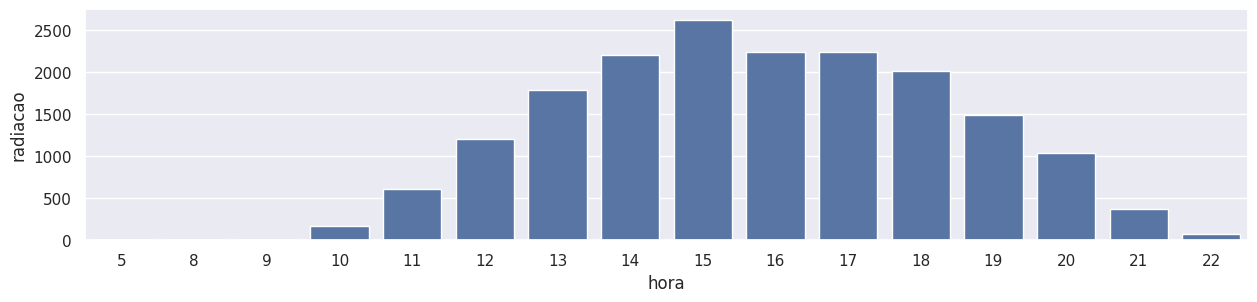

In [92]:
cut_anual_df = filter_between(anual_df, "data", "2024-01-01", "2024-02-01")
cut_anual_df = cut_anual_df[["data_hora", "radiacao", "temp_ins_c"]]

cut_anual_df["hora"] = cut_anual_df["data_hora"].dt.hour

cut_anual_df = cut_anual_df[["hora", "radiacao"]].groupby(['hora']).mean().reset_index()

sns.barplot(cut_anual_df, x="hora", y="radiacao")

Como visto, a partir da 11 e até as 21 que temos valores relevates. Vamos filtrar os dados dentro desse intervalo.

In [105]:
anual_df["hora"] = anual_df["data_hora"].dt.hour

anual_df = filter_between(anual_df, "hora", 11, 21)

**Importante:** Uma característica das séries temporais é que os valore costumam ser próximos em dias próximos. Isso é o que se chama de correlação entre os valores da série.

#### Interpretando uma série temporal
Para saber se uma série temporal é estacionária ou não, há alguns passos:

##### Avaliação visual
Primeiramente observar se a série possui tendência. Vamos fazer um resample por dia.

In [131]:
df_index_resampled = anual_df[["radiacao", "data_hora"]].set_index("data_hora").resample("D").mean()

<Axes: xlabel='data_hora', ylabel='radiacao'>

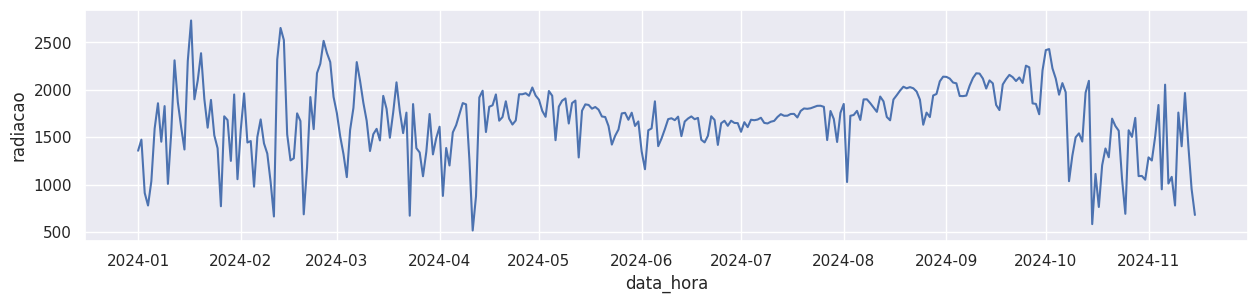

In [133]:
sns.lineplot(data=df_index_resampled, x="data_hora", y="radiacao")

#### AutoCovariance

$$
Cov({X}_t , {X}_{t+h}) = \sum_{i=1}^{N} ({X}_t - \overline{{X}_t}) ({X}_{t+h} - \overline{{X}_{t+h}})
$$


In [108]:
def my_autocov(df, col, interval=1):
    serie = np.array(df[col].to_list())

    # serie = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
    
    xt = serie[:-interval]
    xt1 = serie[interval:]
    n_pairs = len(xt)

    mean_xt = xt.sum(axis=0)/n_pairs
    mean_xt1 = xt1.sum(axis=0)/n_pairs

    dev_xt = xt - mean_xt
    dev_xt1 = xt1 - mean_xt1

    d = {"xt": xt, "xt1": xt1}
    df_new = pd.DataFrame(data=d)

    sns.scatterplot(df_new, x="xt", y="xt1")

    return dev_xt.dot(dev_xt1)/n_pairs
    

Vamos ver a autocovariância em um recorte mensal dos dados. E como os dados são horários, vamos setar dentro da covariância esse período.

786219.1833770014

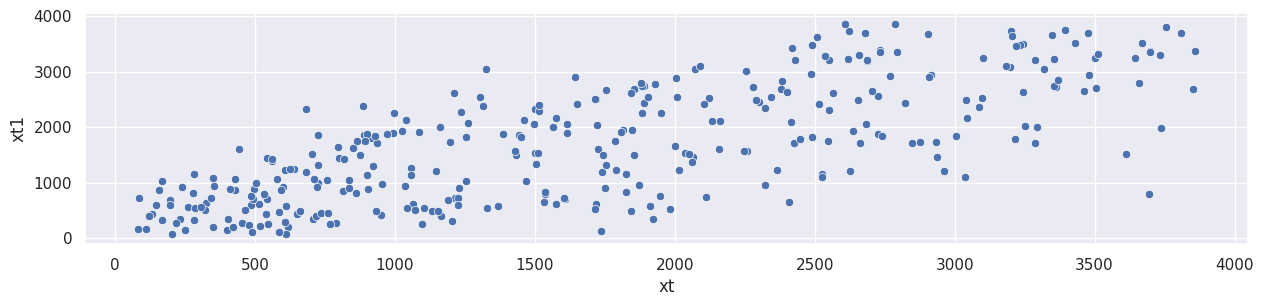

In [114]:
cut_anual_df = filter_between(anual_df, "data", "2024-02-01", "2024-03-01")
cut_anual_df = cut_anual_df[["data_hora", "radiacao"]]
# sns.lineplot(data=cut_anual_df, x="data_hora", y="radiacao")
my_autocov(cut_anual_df, "radiacao", interval=1)

# cut_anual_df

### Analise descritiva
- Pensar em transformação dos dados, para reduzir assimetria
- Checar estacionariedade e tentar atingi-la por meio da decomposição
- Para series estacionarias, analisar autocorrelação e filtragem das series

#### Transformação dos dados
A maioria dos modelos e estimadores são mais eficientes com a ditribuição normal e as relações lineares entre as variaveis. A transformação mais popular é a **log10**. indicada quando a sazonalidade cresce com a tendencia ou a média, ou a distribuição é assimétrica positiva.

##### Distribuição normal
Media, moda e media são iguais

<Axes: >

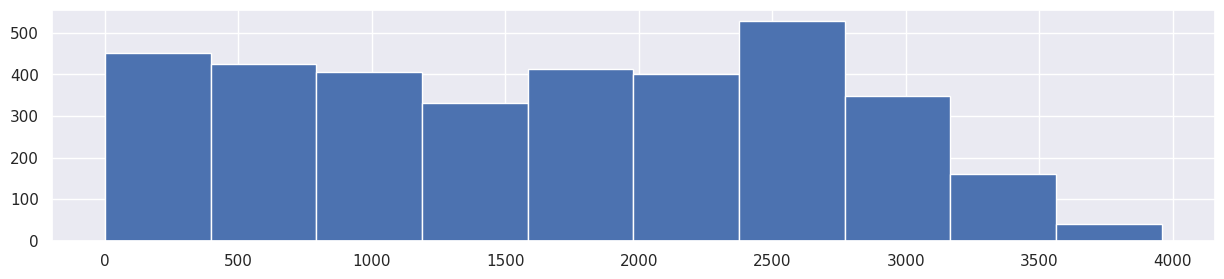

In [115]:
anual_df["radiacao"].hist()

In [118]:
anual_df["rad_log"] = np.log10(anual_df["radiacao"])

array([[<Axes: title={'center': 'radiacao'}>,
        <Axes: title={'center': 'rad_log'}>]], dtype=object)

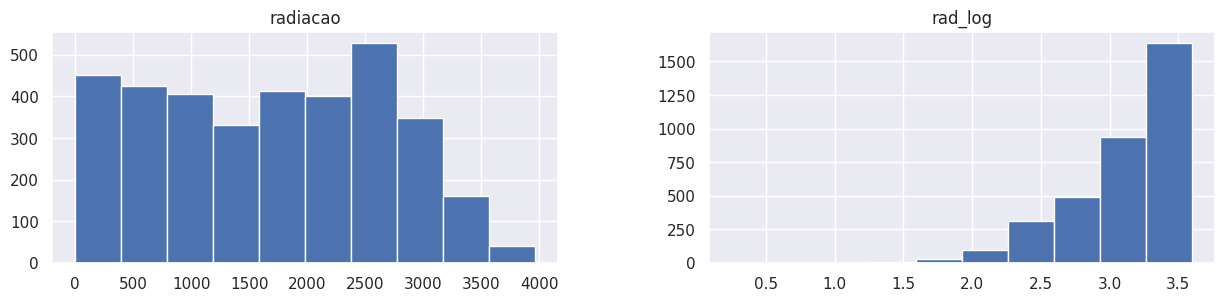

In [119]:
anual_df[["radiacao", "rad_log"]].hist()

In [103]:
list_columns = df.columns
l_final = []
for i in list_columns:
    if 'float' in df[i].dtypes.name:
        l_final.append(i)

#### Amostra para verificar estacionariedade

<Axes: xlabel='data_hora', ylabel='radiacao'>

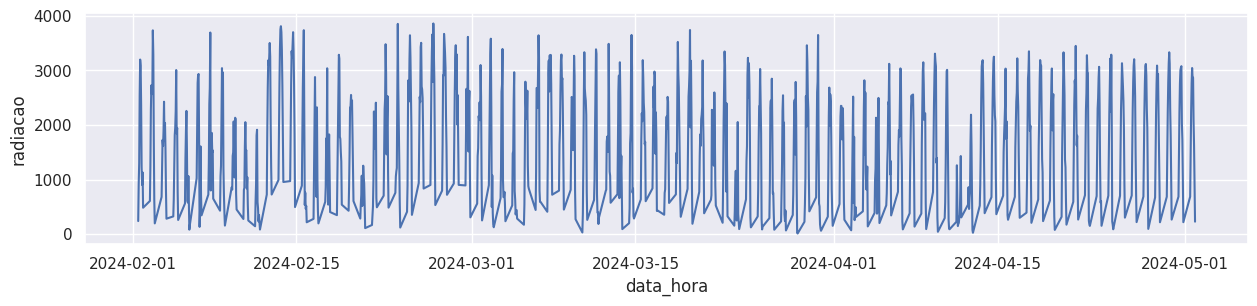

In [142]:
cut_anual_df = filter_between(anual_df, "data", "2024-02-01", "2024-05-01")
cut_anual_df = cut_anual_df[["data_hora", "radiacao", "rad_log"]]
sns.lineplot(data=cut_anual_df, x="data_hora", y="radiacao")

<Axes: xlabel='data_hora', ylabel='rad_log'>

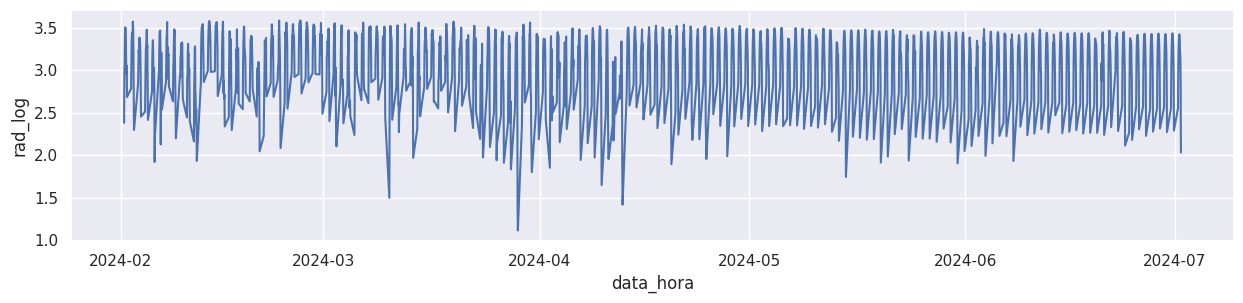

In [138]:
sns.lineplot(data=cut_anual_df, x="data_hora", y="rad_log")

### Teste de estacionariedade

#### Shapiro-Wilk test

In [139]:
res = stats.shapiro(anual_df["rad_log"])
print(res.statistic, res.pvalue)

0.8725391030311584 0.0


In [140]:
mu, sigma = 0, 0.1 

res = stats.shapiro(np.random.normal(mu, sigma, 100))
print(res.statistic, res.pvalue)

0.9859349727630615 0.3700689375400543


#### Teste de estacionariedade AdFuler
Hipótese nula: A śerie contém raiz unitária, portanto é não estacionaria</br>
Hipótese alternativa: A śerie não contém raiz unitária, portanto é estacionaria

In [141]:
ts.adfuller(anual_df["radiacao"])

(-7.135399067951095,
 3.431550615532008e-10,
 30,
 3478,
 {'1%': -3.4322315793282328,
  '5%': -2.862371374547543,
  '10%': -2.5672125553904754},
 52201.119318102625)

**Explicação:** Os resultados são
- primeiro valor: -2.78, o valor crítico dos dados nesse caso.
- segundo valor: 0.059, é o *p-value* (probabilidade da hipotese nula não ser rejeitada?)
- terceiro valor: 15, número de lags usadas na regressão para determinar a estatística *t*. Se fosse 0, então não haverira correlações automáticas voltando para períodos '0'.
- quarto valor: 394, número de observações usadas na análise.
- quinto valor: *t-values* nos intervalos de confiança de 1%, 5% e 10%

O valor crítico -2.78 é maior do que -3.44,-2.86, mas não do que -2.57, a hipótese nula pode ser rejeitada?

### Decomposição

#### Modelo aditivo
Ocorre quando a série (X) é a soma da sua tendência (T), da sua sazonalidade (S) e do seu ruído (R, variáveis aleatórias correlacionadas e com média 0)

$$
X_t = T_t + S_t + R_t
$$


#### Modelo multiplicativo
Quando o efeito sazonal aumenta conforme a tendência aumenta, e é modelado com o produto entre tendência (T), sazonalidade (S) e ruído (R). Quando ocorre esse cenário, aplicamos a função logaritmica log10

$$
X_t = T_t * S_t * R_t
$$

$$
log10(X_t) = log10(T_t * S_t * R_t) = log10(T_t) * log10(S_t) * log10(R_t) = T_t + S_t + R_t
$$

<Axes: xlabel='data_hora', ylabel='radiacao'>

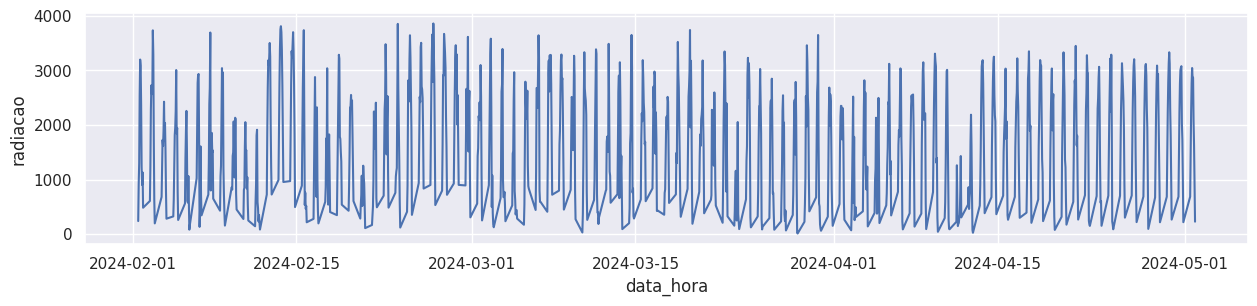

In [146]:
cut_anual_df = filter_between(anual_df, "data", "2024-02-01", "2024-05-01")
cut_anual_df = cut_anual_df[["data_hora", "radiacao", "rad_log"]]

sns.lineplot(data=cut_anual_df, x="data_hora", y="radiacao")

<Axes: xlabel='data_hora', ylabel='rad_log'>

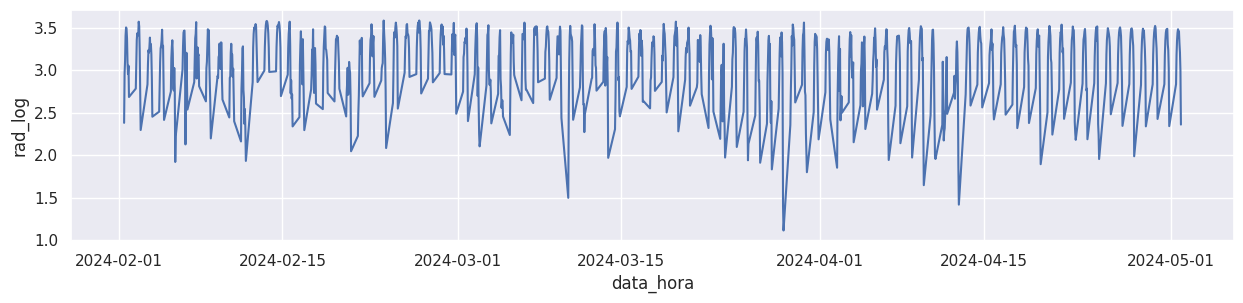

In [147]:
sns.lineplot(data=cut_anual_df, x="data_hora", y="rad_log")

### Diferenciação
Remoção de tendêcnias e/ou efeitos sazonais. Ao inves de observar a série  me si, como anteriormente, eu observo as mudanças. Ex para modelo aditivo:
$$
Y_t = X_{t+1} - X_t
$$

Monitorando as mudanças, remove-se a tendência da série. 

In [149]:
def diferenciacao_aditivo(df_temp, col, periods=1):
    df_temp["shift"] = df_temp[col].shift(periods=periods, fill_value=0)
    df_temp["diff"] = df_temp[col] - df_temp["shift"]

    return df_temp

##### Radiacao (modelo aditivo)

In [155]:
df_temp = cut_anual_df[["data_hora", "radiacao"]]
df_temp = diferenciacao_aditivo(df_temp, "radiacao")

<Axes: xlabel='data_hora', ylabel='diff'>

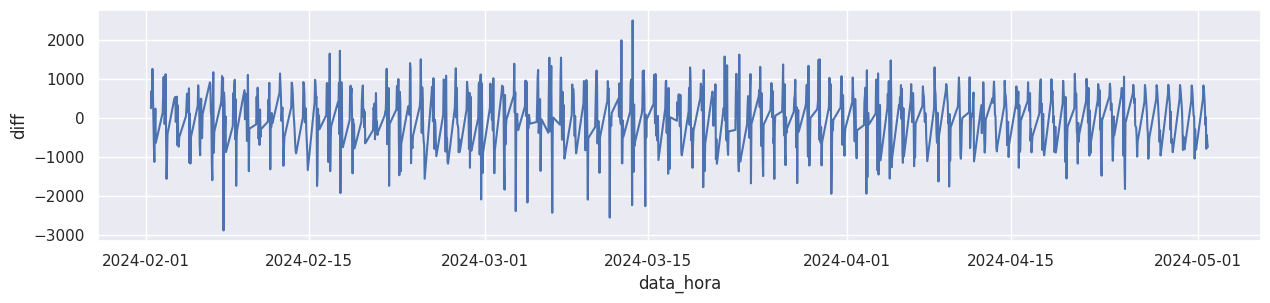

In [156]:
sns.lineplot(data=df_temp, x="data_hora", y="diff")

Ex para modelo mutiplicativo:

$$
Y_t = log10(X_{t+1}) - log10(X_t)
$$
que é + - 
$$
(X_{t+1} - X_t)/X_t
$$

In [152]:
def diferenciacao_multiplicativo(df_temp, col, periods=1):
    df_temp["shift"] = df_temp[col].shift(periods=periods, fill_value=0)
    df_temp["diff"] = np.log10(df_temp[col]) - np.log10(df_temp["shift"])

    return df_temp

##### Radiacao (modelo multiplicativo)

In [153]:
df_temp = cut_anual_df[["data_hora", "radiacao"]]
df_temp = diferenciacao_multiplicativo(df_temp, "radiacao")

/usr/local/lib/python3.8/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='data_hora', ylabel='diff'>

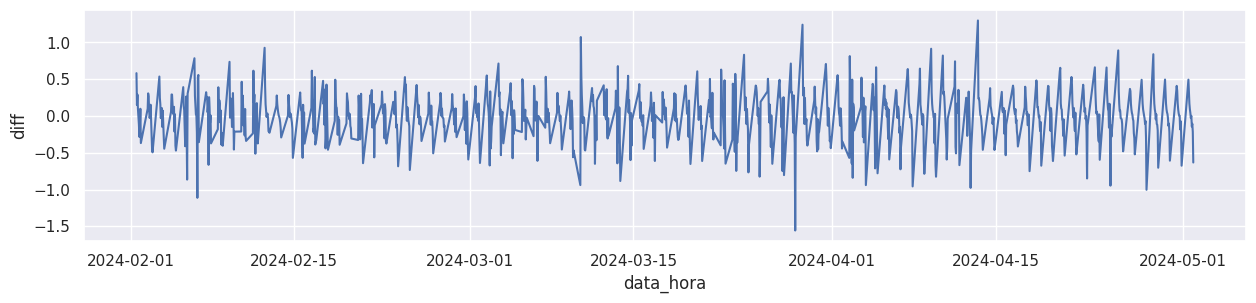

In [154]:
sns.lineplot(data=df_temp, x="data_hora", y="diff")

<Axes: >

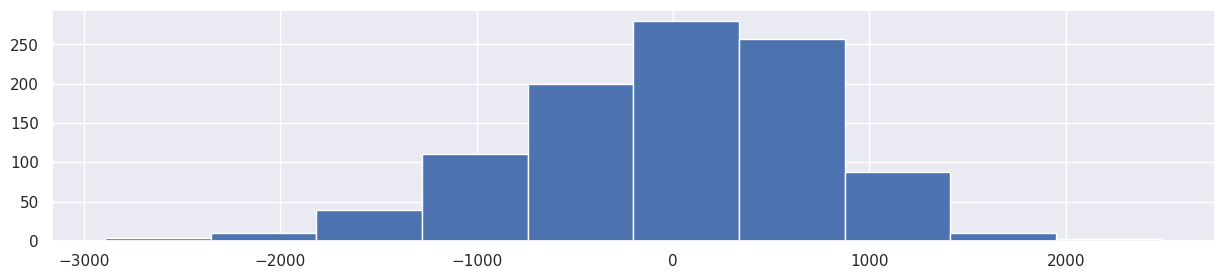

In [157]:
df_temp["diff"].hist()

##### Umidade (modelo aditivo)

<Axes: >

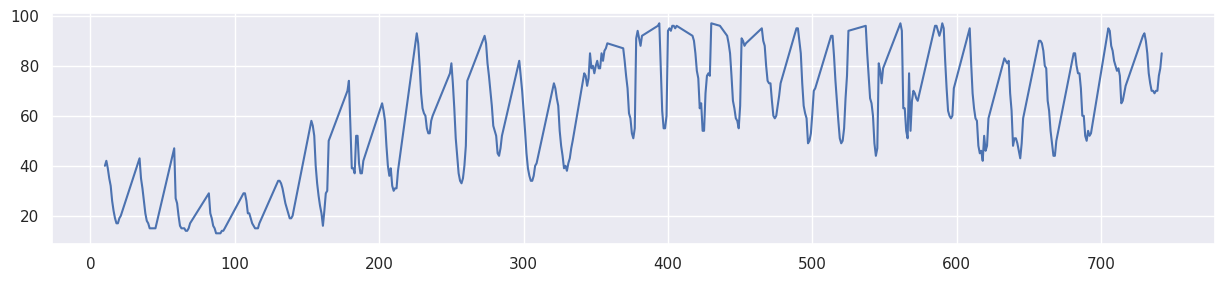

In [106]:
df["umi_min_perc"].plot()

<Axes: xlabel='data_hora', ylabel='diff'>

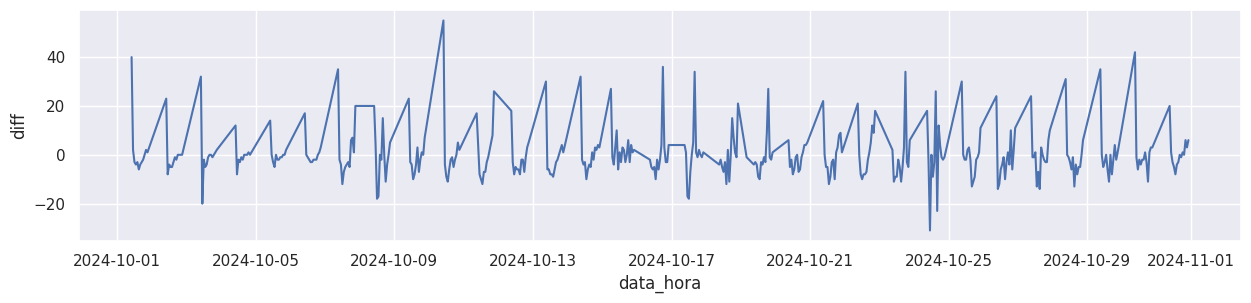

In [159]:
df_temp = df[["data_hora", "umi_min_perc"]]
df_temp = diferenciacao_aditivo(df_temp, "umi_min_perc")

sns.lineplot(data=df_temp, x="data_hora", y="diff")

##### Umidade (modelo multiplicativo)

/usr/local/lib/python3.8/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='data_hora', ylabel='diff'>

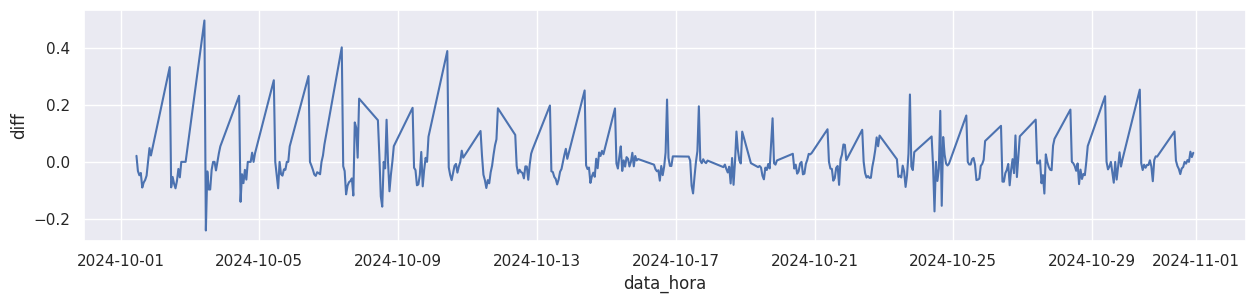

In [160]:
df_temp = df[["data_hora", "umi_min_perc"]]
df_temp = diferenciacao_multiplicativo(df_temp, "umi_min_perc")

sns.lineplot(data=df_temp, x="data_hora", y="diff")

Maior variância para a série que não foi transformada com o Log10

#### Remoção de sazonalidade por diferenciação

In [216]:
# temp_anual_df = anual_df[(anual_df["mes"] >=9) & (anual_df["mes"] <=11)]
# sns.lineplot(data=temp_anual_df, x="data", y="radiacao")
# temp_anual_df.T
# anual_df

##### Vento

In [164]:
temp_anual_df = anual_df[["data", "vel_vento_ms"]].groupby(['data']).mean().reset_index()
temp_anual_mes_df = anual_df[["mes", "vel_vento_ms"]].groupby(['mes']).mean().reset_index()

<Axes: xlabel='data', ylabel='vel_vento_ms'>

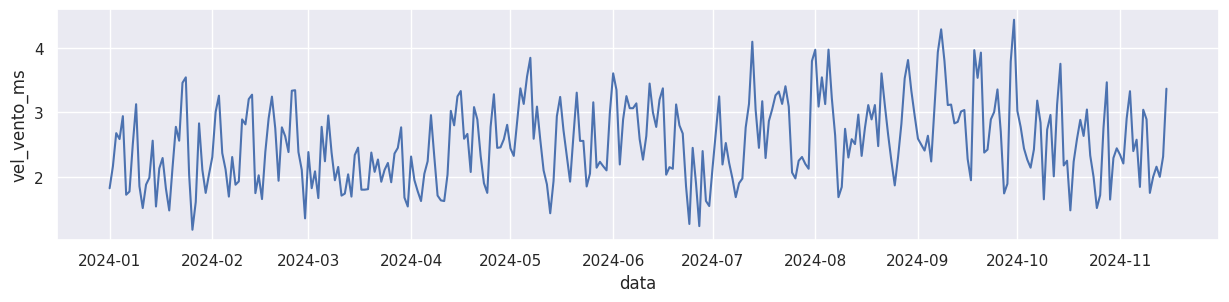

In [169]:
sns.lineplot(data=temp_anual_df, x="data", y="vel_vento_ms")

##### Radiacao

In [178]:
rad_anual_df = anual_df[["data", "radiacao"]].groupby(['data']).mean().reset_index()
rad_anual_mes_df = anual_df[["mes", "radiacao"]].groupby(['mes']).mean().reset_index()

<Axes: xlabel='data_hora', ylabel='radiacao'>

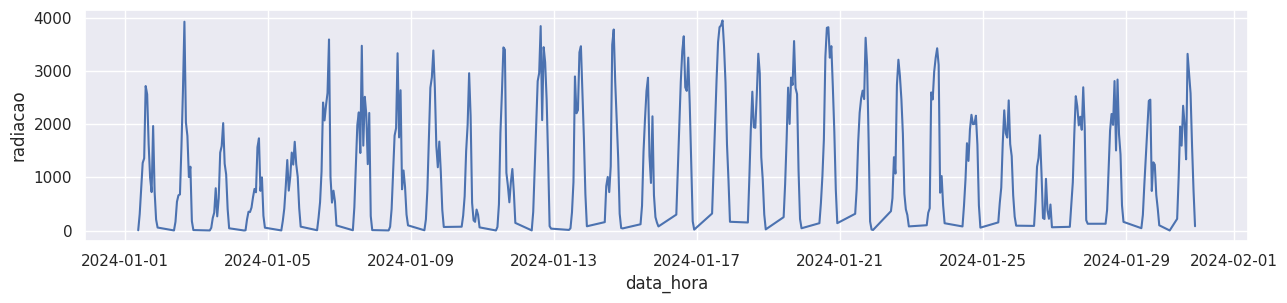

In [248]:
# Serie normal
df_temp = anual_df[["data", "data_hora", "radiacao"]]
df_temp = df_temp[(df_temp["data"] >= "2024-01-01") & (df_temp["data"] <= "2024-01-30")]
sns.lineplot(data=df_temp, x="data_hora", y="radiacao")

<Axes: xlabel='data_hora', ylabel='diff'>

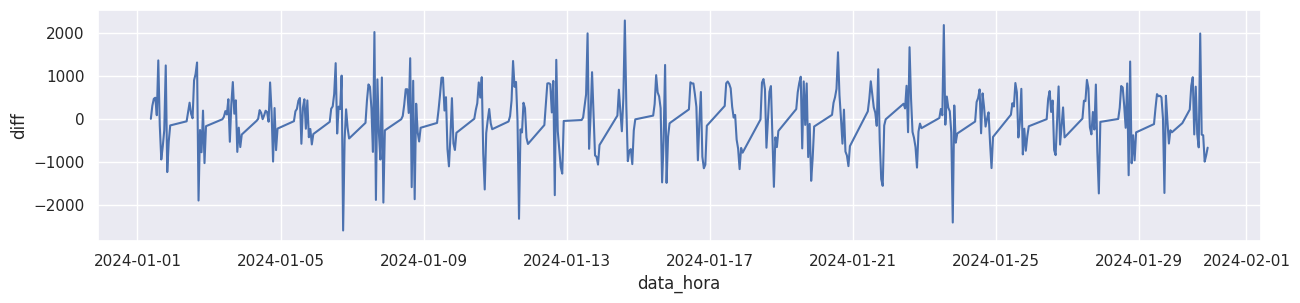

In [249]:
# Remover sazonalidade
df_temp = diferenciacao_aditivo(df_temp, "radiacao", 1)
sns.lineplot(data=df_temp, x="data_hora", y="diff")

<Axes: xlabel='data_hora', ylabel='diff'>

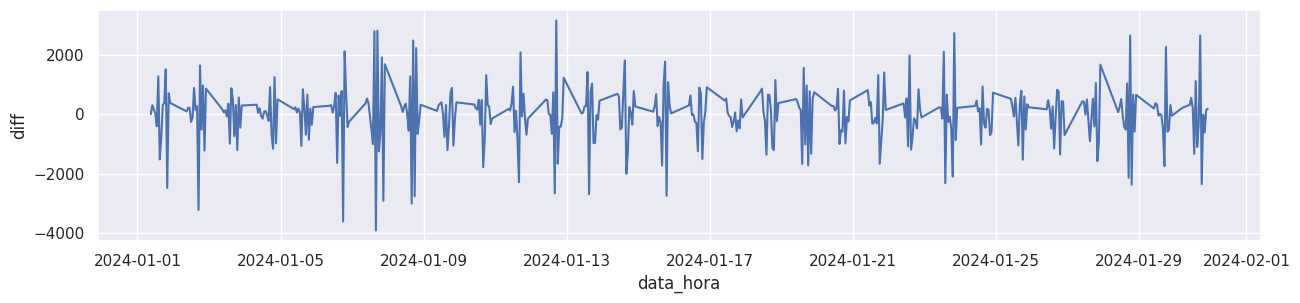

In [250]:
# Remover tendencia
df_temp = diferenciacao_aditivo(df_temp, "diff", 1)
sns.lineplot(data=df_temp, x="data_hora", y="diff")

<Axes: >

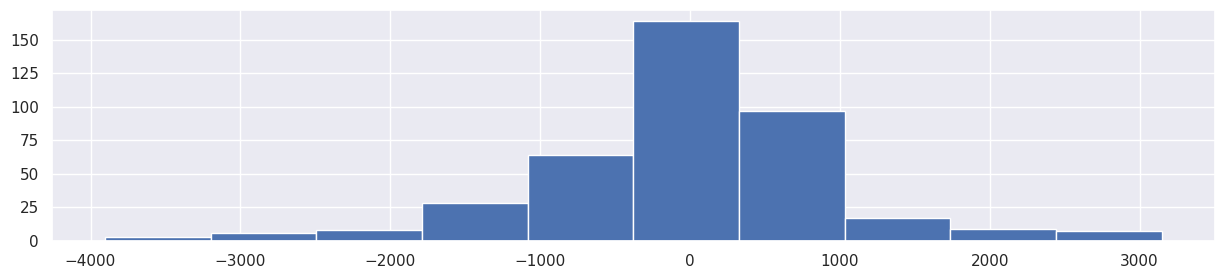

In [254]:
df_temp["diff"].hist()

### Filtragem

Para séries sem efeitos sazonais:

$$
T_t = \frac{1}{2n+1} \sum_{i=-n}^{n} X_{t+i}
$$

**[REVER FOMULA]** Caso seja sazonal, utilizar a formula da media movel sazonal:

$$
T_t = \frac{1}{d} \sum_{i=-n}^{n} \frac{1}{2} X_{t-q}, X_{t-q+1}...X_{t+q-1} + \frac{1}{2}X_{t+q}
$$



In [167]:
# temp_anual = anual_df[["mes", "vel_vento_ms"]]
temp_anual = anual_df[(anual_df["data"] >= "2024-01-01") & (anual_df["data"] <= "2024-01-16")]
# df_temp = df_temp[(df_temp["data"] >= "2024-01-01") & (df_temp["data"] <= "2024-01-30")]
# temp_anual.head().T

<Axes: xlabel='data_hora', ylabel='pressao_ins_hpa'>

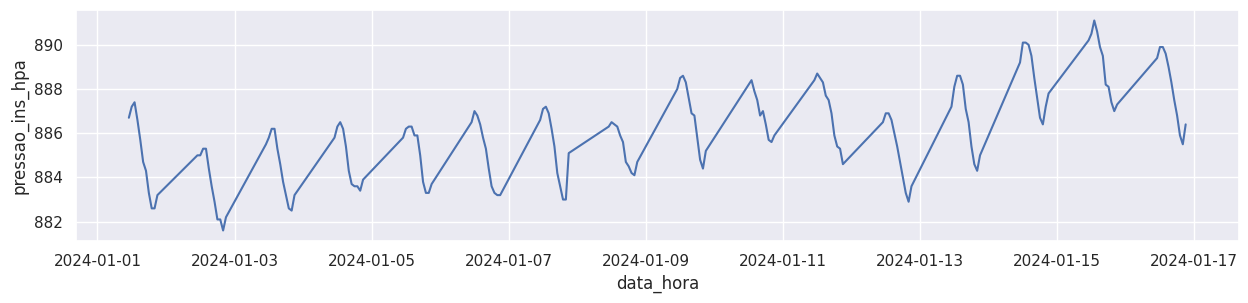

In [168]:
sns.lineplot(data=temp_anual, x="data_hora", y="pressao_ins_hpa")

In [169]:
temp_anual = temp_anual[["data_hora", "pressao_ins_hpa"]]

In [170]:
temp_anual["log"] = np.log10(temp_anual["pressao_ins_hpa"])

<Axes: xlabel='data_hora', ylabel='log'>

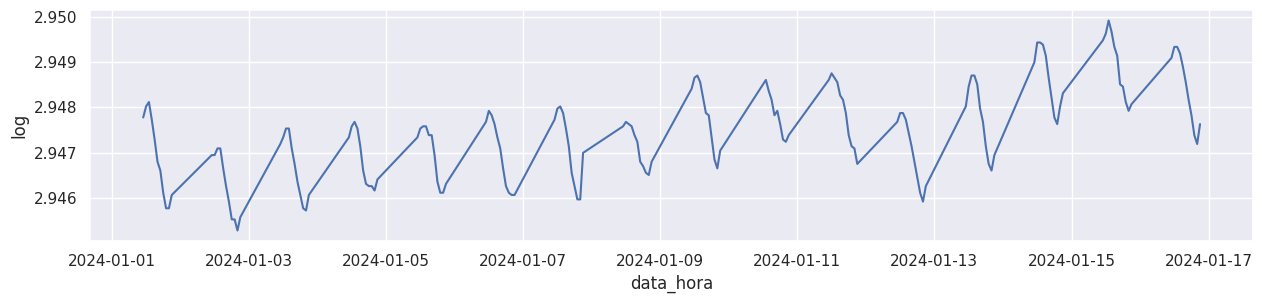

In [171]:
sns.lineplot(data=temp_anual, x="data_hora", y="log")

<Axes: >

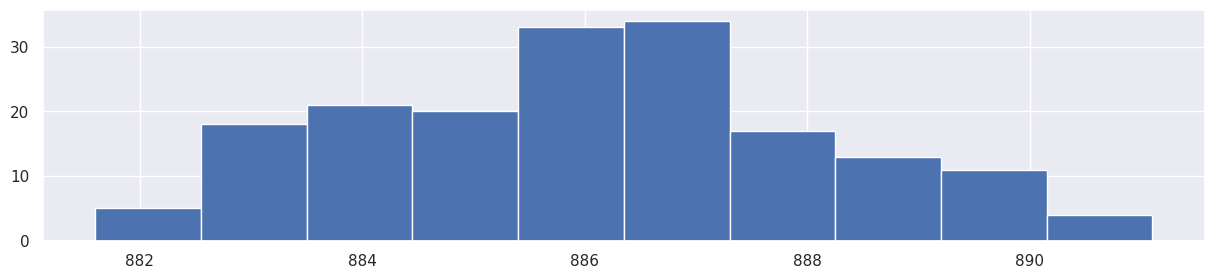

In [172]:
temp_anual["pressao_ins_hpa"].hist()

In [315]:
# temp_anual = anual_df
# temp_anual["week"] = temp_anual["data"].dt.isocalendar().week
# temp_anual_grouped = temp_anual[["week", "radiacao"]].groupby(['week']).mean().reset_index()
# sns.lineplot(data=temp_anual_grouped, x="week", y="radiacao")

In [312]:
# Aplicar a diferenciacao nosdados horarios usando 24h ou o numero d acordo com a remocao que fiz

In [173]:
temp_anual["ma"] = temp_anual["log"].rolling(window=14, min_periods=1, center=True).mean()
# temp_anual["ma"] = temp_anual["log"].rolling('2D').mean().shift(-1)


# temp_anual["divided"] = temp_anual["shift"].shift(periods=1, fill_value=0)

In [174]:
temp_anual

,data_hora,pressao_ins_hpa,log,ma
11,2024-01-01 11:00:00,886.7,2.947777,2.947475
12,2024-01-01 12:00:00,887.2,2.948022,2.947304
13,2024-01-01 13:00:00,887.4,2.948119,2.947133
14,2024-01-01 14:00:00,886.6,2.947728,2.946996
15,2024-01-01 15:00:00,885.7,2.947287,2.946911
...,...,...,...,...
377,2024-01-16 17:00:00,887.5,2.948168,2.948392
378,2024-01-16 18:00:00,886.8,2.947826,2.948421
379,2024-01-16 19:00:00,885.9,2.947385,2.948354
380,2024-01-16 20:00:00,885.5,2.947189,2.948244


<Axes: xlabel='data_hora', ylabel='log'>

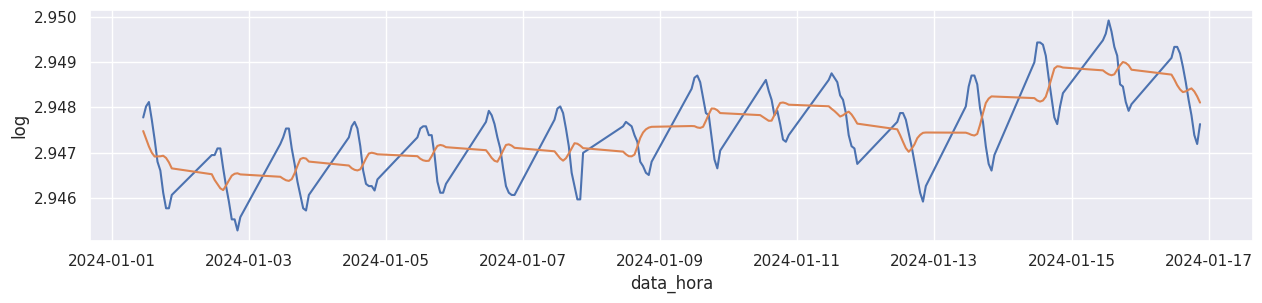

In [175]:
sns.lineplot(data=temp_anual, x="data_hora", y="log")
sns.lineplot(data=temp_anual, x="data_hora", y="ma")